In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('marketing_campaign_data.csv')

# Data Null dan Duplikat

In [36]:
# Missing Values
df.isna().sum()

Unnamed: 0              0
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntCoke                 0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [37]:
df.dropna(inplace=True)

In [38]:
# Nilai Duplikat
df.duplicated().sum()

np.int64(0)

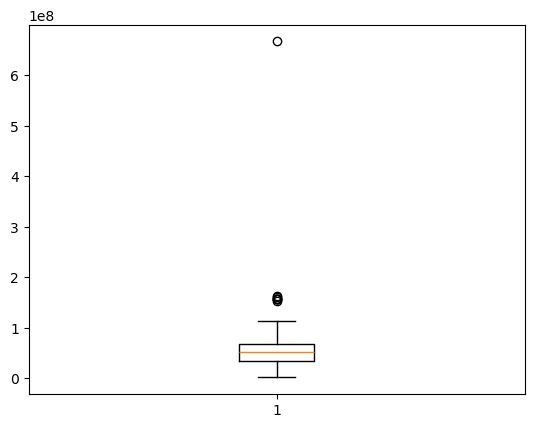

In [39]:
#Outliers
plt.boxplot(df['Income'])
plt.show()

In [40]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Income'] < (Q1 - 1.5 * IQR)) | (df['Income'] > (Q3 + 1.5 * IQR))]

print("Banyaknya Nilai Outliers:", len(outliers))

Banyaknya Nilai Outliers: 8


In [41]:
# Menghapus nilai outliers
df = df[~((df['Income'] < (Q1 - 1.5 * IQR)) | (df['Income'] > (Q3 + 1.5 * IQR)))]

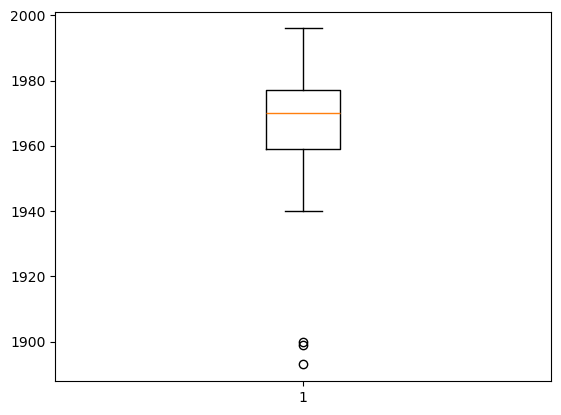

In [42]:
plt.boxplot(df['Year_Birth'])
plt.show()

In [43]:
Q1 = df['Year_Birth'].quantile(.25)
Q3 = df['Year_Birth'].quantile(.75)
IQR = Q3-Q1

outliers = df[(df['Year_Birth']<(Q1 - 1.5 * IQR)) | (df['Year_Birth']>(Q3+1.5*IQR))]
print('Nilai outliers pada Tahun Lahir: ',len(outliers))

Nilai outliers pada Tahun Lahir:  3


In [44]:
df = df[~((df['Year_Birth']<(Q1 - 1.5 * IQR)) | (df['Year_Birth']>(Q3+1.5*IQR)))]

# Feature Selection

In [45]:
df.drop(columns=['Unnamed: 0','ID','Z_CostContact','Z_Revenue'], inplace=True)

In [ ]:
#Binary Encoding
df['Is_Couple'] = np.where(((df['Marital_Status']=='Menikah') | (df['Marital_Status']=='Bertunangan')),1,0)
df['Is_SMA']=np.where(df['Education']=='SMA',1,0)

In [50]:
df['Usia'] = 2014 - df['Year_Birth']
df.head()
def rentangusia(Usia):
    if Usia<=30:
        return 'Muda'
    elif Usia<=55:
        return 'Tua'
    else:
        return 'Lansia'

df['rentang'] = df['Usia'].apply(rentangusia)

In [51]:
Urutan = {'Muda': 1, 'Tua': 2, 'Lansia': 3}
df['rentang'] = df['rentang'].map(Urutan)
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Is_Couple,Is_SMA,Anak,cmp_masuk,Spent,deals_rate,conversion_rate,Usia,rentang
0,1957,S1,Lajang,58138000.0,0,0,04-09-2012,58,635000,88000,546000,172000,88000,88000,3,8,10,4,7,0,0,0,0,0,0,1,0,0,0,0,1617000,0.120000,0.533333,57,3
1,1954,S1,Lajang,46344000.0,1,1,08-03-2014,38,11000,1000,6000,2000,1000,6000,2,1,1,2,5,0,0,0,0,0,0,0,0,0,2,0,27000,0.333333,0.166667,60,3
2,1965,S1,Bertunangan,71613000.0,0,0,21-08-2013,26,426000,49000,127000,111000,21000,42000,1,8,2,10,4,0,0,0,0,0,0,0,1,0,0,0,776000,0.047619,0.666667,49,2
3,1984,S1,Bertunangan,26646000.0,1,0,10-02-2014,26,11000,4000,20000,10000,3000,5000,2,2,0,4,6,0,0,0,0,0,0,0,1,0,1,0,53000,0.250000,0.250000,30,1
4,1981,S3,Menikah,58293000.0,1,0,19-01-2014,94,173000,43000,118000,46000,27000,15000,5,5,3,6,5,0,0,0,0,0,0,0,1,0,1,0,422000,0.263158,0.500000,33,2
